# Check Example Data Split

This notebook checks properties of example split to see whether desired properties are matched.

In [1]:
import sys
import os

os.chdir("..")

In [2]:
import pandas as pd

full_data = pd.read_csv("metadata_tables/full_data.csv")
train_data = pd.read_csv("metadata_tables/train_data.csv")
val_data = pd.read_csv("metadata_tables/val_data.csv")

Disjoint and sums to the whole data:

In [11]:
t = set(train_data["image_path"])
v = set(val_data["image_path"])

print("Train:", len(t))
print("Val:", len(v))

assert len(t) + len(v) == len(full_data), "Some files are missing"
assert len(t & v) == 0, "Some are contained multiple times"

Train: 2072
Val: 518


Correct ratio:

In [5]:
import math

assert math.isclose( len(t) / len(v), 4 ), "Wrong split ratio"

Distribution of cities preserved:

In [7]:
import matplotlib.pyplot as plt


def show_hist(df: pd.DataFrame) -> None:
    counts = df["city"].value_counts()
    plt.figure(figsize=(10, 5))
    plt.bar(counts.index, counts.values, width=0.6)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

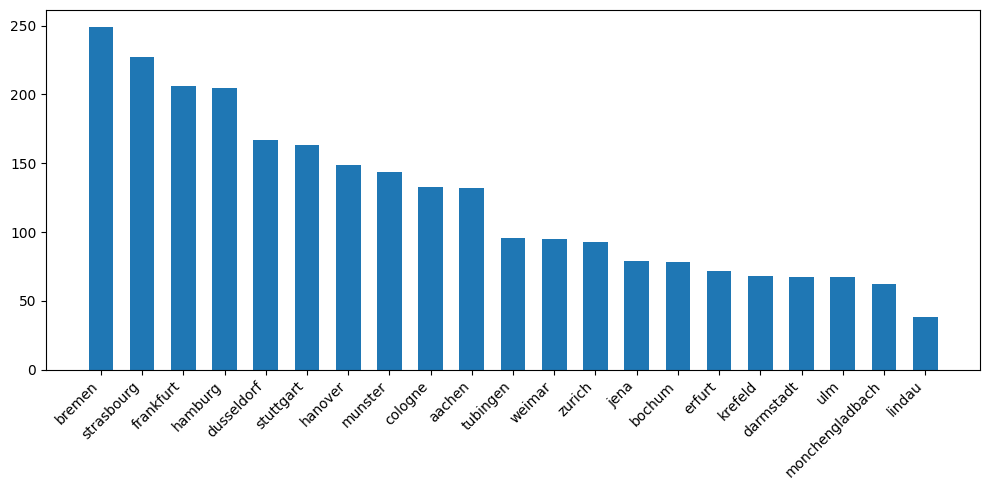

In [8]:
show_hist(full_data)

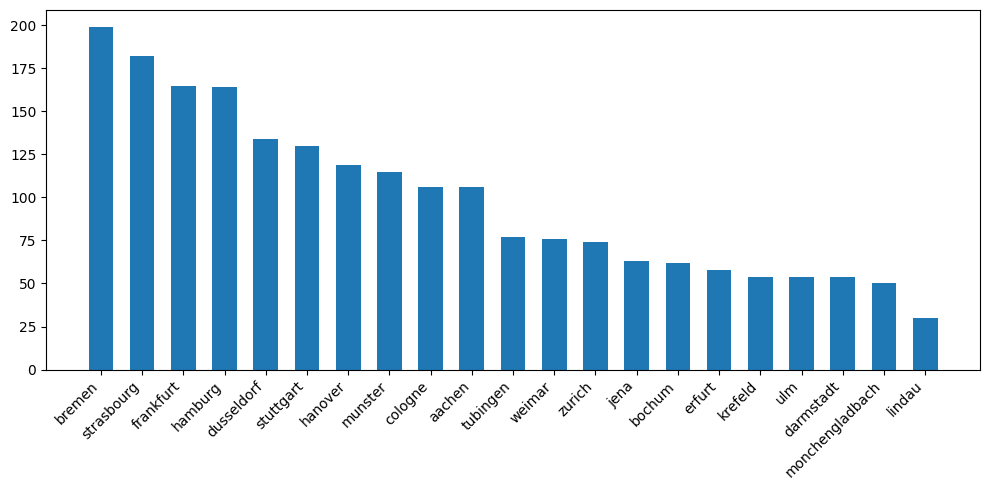

In [9]:
show_hist(train_data)

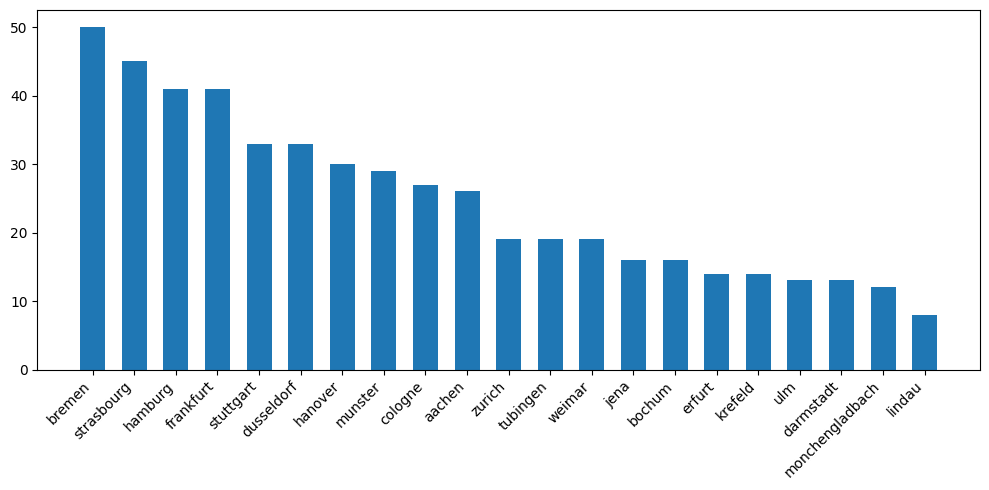

In [10]:
show_hist(val_data)